In [31]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [32]:

%cd /content/drive/MyDrive/Manuscript_Segmentation/ManuscriptSegmentation
%pip install -r requirements.txt
!pip install aspose-words

/content/drive/MyDrive/Manuscript_Segmentation/ManuscriptSegmentation
ERROR: Could not find a version that satisfies the requirement TorchCRF==0.7.2 (from versions: 1.0.0, 1.0.1, 1.0.2, 1.0.3, 1.0.4, 1.0.5, 1.0.6, 1.0.7, 1.0.8, 1.1.0)
ERROR: No matching distribution found for TorchCRF==0.7.2


In [33]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)  # должно быть 'cuda'

cuda


# 1. Извлечение рукописи


In [34]:
import unicodedata
import pandas as pd
import numpy as np

import os
print(os.getcwd())  # Покажет текущую папку
print(os.listdir()) # П

/content/drive/MyDrive/Manuscript_Segmentation/ManuscriptSegmentation
['notebooks', '.ipynb_checkpoints', 'data', 'requirements.txt']


In [35]:
# 1. Установка системной утилиты
!apt-get install -y antiword

import os
import re
import unicodedata
import notebooks.get_words_corpus as wc

text = wc.get_raw_lines_from_doc('data/193-210.doc')
words_corpus = wc.get_clean_words(text)

print(f"Корпус собран. Всего слов: {len(words_corpus)}")
print("Первые 15 слов корпуса:")
print(words_corpus[:15])
#-----Пока не обрабатывает года, но обрабатывает номера страницу, буквы между рукописями

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
antiword is already the newest version (0.37-16).
0 upgraded, 0 newly installed, 0 to remove and 25 not upgraded.
безазорнъ҇хъ лиць кромѣ ходѧть · женѹ имать или рабъ҇нѧ · безазорьноѥ себе ѡ семь хранѧ · аще ли пре
Корпус собран. Всего слов: 4687
Первые 15 слов корпуса:
['безазорнъ҇хъ', 'лиць', 'кромѣ', 'ходѧть', 'женѹ', 'имать', 'или', 'рабъ҇нѧ', 'безазорьноѥ', 'себе', 'ѡ', 'семь', 'хранѧ', 'аще', 'ли']


#2. Создание Обучающей, тестовой и валидоционной выборок. Создание целевой переменной



In [36]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

from os.path import split
from sklearn.model_selection import train_test_split

split_index_1 = int(len(words_corpus) * 0.7)
split_index_2 = int(len(words_corpus) * 0.8)
train_text = words_corpus[:split_index_1] + words_corpus[split_index_2:]
test_text = words_corpus[split_index_1:split_index_2]

split_for_val = int(len(train_text) * 0.8)
val_text = train_text[split_for_val:]
train_text = train_text[:split_for_val]

words_corpus = train_text

In [37]:
def prepare_chars_and_labels(words_list):
    chars = []
    labels = []
    for word in words_list:
        if not word or not isinstance(word, str):
            continue
        # Первая буква слова — класс 1 (Begin)
        chars.append(word[0].lower())
        labels.append(1)
        # Остальные буквы слова — класс 0 (Inside)
        for char in word[1:]:
            chars.append(char.lower())
            labels.append(0)
    return chars, labels

train_chars, train_labels = prepare_chars_and_labels(train_text)
test_chars, test_labels = prepare_chars_and_labels(test_text)
val_chars, val_labels = prepare_chars_and_labels(val_text)

print("склеенный текст:", train_chars[:15])
print("метки:          ", train_labels[:15])

склеенный текст: ['б', 'е', 'з', 'а', 'з', 'о', 'р', 'н', 'ъ', '҇', 'х', 'ъ', 'л', 'и', 'ц']
метки:           [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0]


In [38]:
unique_chars = sorted(list(set(train_chars + test_chars + val_chars)))
char_to_idx = {char: idx + 1 for idx, char in enumerate(unique_chars)}
char_to_idx['[PAD]'] = 0  # Токен отступа для выравнивания длин

# Переводим буквы в их числовые индексы
train_ids = [char_to_idx[c] for c in train_chars]
test_ids = [char_to_idx[c] for c in test_chars]
val_ids = [char_to_idx[c] for c in val_chars]

print("Размер старославянского словаря из рукописей:", len(unique_chars))


Размер старославянского словаря из рукописей: 43


# 3. Настройка и базовое обучение на модели LSTM

In [39]:
class BiLSTMSegmentation(nn.Module):
  def __init__(self, output_dim, bidirectional, vocab_size, embedding_dim = 64, hidden_dim = 64, num_layers = 2, dropout = 0.2):
      super().__init__()
      self.embedding = nn.Embedding(vocab_size + 1, embedding_dim)
      self.lstm = nn.LSTM(embedding_dim, hidden_dim, bidirectional=bidirectional, batch_first=True)
      #self.dropout = nn.Dropout(dropout) # как бы регулярищатор между nn и классификатором, он с вер p обнуляет координаты в h, тем самым модель привыкает обучаться на потерянной инфе(не переобучается)
      self.fc = nn.Linear(hidden_dim * 2, output_dim)

  def forward(self, x):
    embedding = self.embedding(x)
    out, hidden_out = self.lstm(embedding)
    #out  = self.dropout(out)
    out = self.fc(out)
    return out

  def __copy__(self):
    return self


In [40]:
class CharSegmentationDataset(Dataset):
    def __init__(self, ids_list, labels_list, seq_len=64):
        self.seq_len = seq_len
        # Нарезаем на куски фиксированной длины
        num_samples = len(ids_list) // seq_len
        labels_list = labels_list + [1] * len(labels_list)

        self.X = torch.tensor(ids_list[:num_samples * seq_len]).view(num_samples, seq_len)
        self.y = torch.tensor(labels_list[:num_samples * seq_len]).view(num_samples, seq_len)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = CharSegmentationDataset(train_ids, train_labels, seq_len=64)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

test_dataset = CharSegmentationDataset(test_ids, test_labels, seq_len=64)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

val_dataset = CharSegmentationDataset(val_ids, val_labels, seq_len=64)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

In [41]:
criterion = nn.CrossEntropyLoss()
model = BiLSTMSegmentation(2, True, len(unique_chars))
optimizer = optim.Adam(model.parameters(), lr = 0.001)

for i in range(20):
  total_loss = 0
  for batch in train_loader:
    X, y = batch
    optimizer.zero_grad()
    pred = model.forward(X)
    pred = pred.reshape(-1, pred.shape[-1])     # (batch*seq_len, 2), представляем размер в 2D
    y = y.reshape(-1)
    loss = criterion(pred, y)
    loss.backward()
    optimizer.step()
    total_loss += loss.item()
  if i % 8 == 0:
      print(f"Epoch {i + 1}, Loss: {total_loss / len(train_loader)}")

   # Эпохи

Epoch 1, Loss: 0.6101127505302429
Epoch 9, Loss: 0.37030441164970396
Epoch 17, Loss: 0.2574512600898743


In [42]:
def segment_raw_text(input_string, model, char_to_idx):
    model.eval()
    with torch.no_grad():

        ids = [char_to_idx.get(char.lower(), 0) for char in input_string]
        input_tensor = torch.tensor([ids])

        logits = model.forward(input_tensor)

        predictions = torch.argmax(logits, dim=-1).squeeze(0).tolist()

        result = []
        for char, pred in zip(input_string, predictions):
            if pred == 1 and result:
                result.append(" ")
            result.append(char)

        return "".join(result)

# Проверка
raw_test_string = "внесеныисправленияприподведенииразночтений"
segmented_output = segment_raw_text(raw_test_string, model, char_to_idx)
segmented_output

'в не сеныисправления приподведени иразночтений'

# 4. Подбор гиперпараметра, Валидация

Лучший гиперпаарметр lr и weight_decay согласно accuracy метрике на валидационной выборке: 
 lr - 0.01, weight decay - 1e-06, threshold - 0.7424506545066833: f1 - 0.6027561409020459

Лучший гиперпараметр, данные. lr, weight_decay: (0.01, 1e-06)


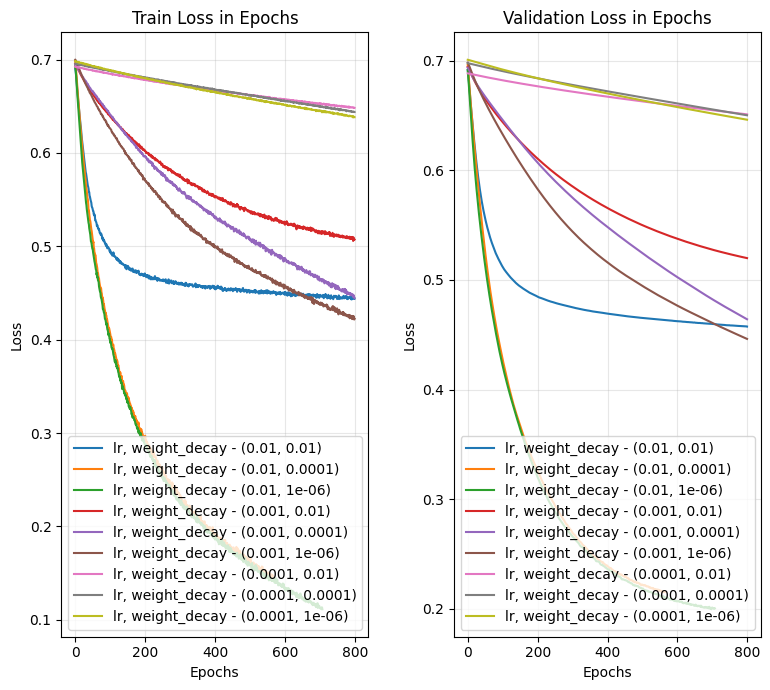

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, precision_recall_curve

def get_word_spans(labels):
    spans, start = [], 0
    for i, l in enumerate(labels):
        if l == 1 and i > 0:
            spans.append((start, i)); start = i
    spans.append((start, len(labels)))
    return set(spans)

history = {}
lrs = [0.01, 0.001, 0.0001]
weight_decays = [1e-2, 1e-4, 1e-6]


def train_and_validate(lr, weight_decay, epochs = 800):
  val_losses, train_losses = [], []
  accuracies = []
  best_accuracy = 0

  best_val_loss, best_state = float('inf'), None
  patience = 10
  no_improve = 0

  # 1. Веса
  class_counts = np.bincount(train_labels)
  weights = torch.tensor(
      len(train_labels) / (2.0 * class_counts), dtype=torch.float32).to(device) ## чистый argmax предсказывает почти только 0, из-за несбалансированности train выборки
  # будем добавлять веса в лосе, чтобы чаще учитывать loss, (но со смягчением, чтобы не изменить направленность классов). Без этого Accuracy =
  criterion = nn.CrossEntropyLoss(weight= weights)
  model = BiLSTMSegmentation(2, True, len(unique_chars)).to(device)
  optimizer = optim.SGD(params = model.parameters(), lr = lr, momentum = 0.9, weight_decay = weight_decay)

  # 2. Обучение
  for i in range(epochs):
    model.train()
    total_loss = 0
    for batch in train_loader:
      X, y = batch
      X, y = X.to(device), y.to(device)
      optimizer.zero_grad()
      pred = model.forward(X)
      pred = pred.reshape(-1, pred.shape[-1])     # (batch*seq_len, 2)
      y = y.reshape(-1)
      loss = criterion(pred, y)
      loss.backward()
      optimizer.step()
      total_loss += loss.item()

    train_losses.append(total_loss / len(train_loader))

    # 3. Валидация в одной эпохе
    model.eval()
    with torch.no_grad():
      X_val, y_val = val_dataset.X.to(device), val_dataset.y.to(device)
      preds = model.forward(X_val)
      preds = preds.reshape(-1, preds.shape[-1])
      y_val = y_val.reshape(-1)
      loss = criterion(preds, y_val)
      val_losses.append(loss.item())
      accuracy = (torch.argmax(preds, dim = 1) == y_val).float().mean().item()

      accuracies.append(accuracy)
      best_accuracy = max(accuracies)

    if loss.item() < best_val_loss - 1e-4:
        best_val_loss = loss.item()
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= patience:
            break



  model.load_state_dict(best_state)
  # Датафрейм для динамикка loss через эпохи
  history[(lr, weight_decay)] = {
    'train_loss': train_losses, 'val_loss': val_losses, 'accuracy': accuracies, 'best_accuracy': [best_accuracy] * len(train_losses)
  }

  # 4 Подбор treshold для буста f1_score
  probs = torch.softmax(model(val_dataset.X.to(device)).reshape(-1, 2), dim=-1)[:, 1].detach().cpu().numpy()
  y_true = val_dataset.y.reshape(-1).numpy()


  f1_snaps = []
  _, _, thresholds = precision_recall_curve(y_true, probs) # берем вектор софтмаксный, и смотрим метрику для разных treshold

  for t in thresholds:
    probs_ = (probs > t).astype(int)
    probs_snaps, y_true_snaps = get_word_spans(probs_), get_word_spans(y_true)
    tp = len(probs_snaps & y_true_snaps)
    precision = tp / len(probs_snaps)
    recall = tp / len(y_true_snaps)

    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    f1_snaps.append(f1)

  best_threshold = thresholds[np.argmax(f1_snaps[:-1])]
  # f1, чтобы учитывать и recall и precision (чтоб сегментация не была редкостью,
  #но и слишком часто она не применялась)

  return model, best_threshold, max(f1_snaps)



model_main, threshold_main = None, None
best_f1, best_lr_wdecay,  = 0 , (0, 0)
for lr in lrs:
  for weight_decay in weight_decays:
    _1, _2, f1 = train_and_validate(lr = lr, weight_decay = weight_decay)
    if f1 > best_f1:
      best_f1, best_lr_wdecay = f1, (lr, weight_decay)
      model_main = _1
      threshold_main = _2

print(f'Лучший гиперпаарметр lr и weight_decay согласно accuracy метрике на валидационной выборке: \n \
lr - {best_lr_wdecay[0]}, weight decay - {best_lr_wdecay[1]}, threshold - {threshold_main}: f1 - {best_f1}')
print()



df_best = pd.DataFrame(history[best_lr_wdecay])
print(f'Лучший гиперпараметр, данные. lr, weight_decay: {best_lr_wdecay}')
df_best

fig, axes = plt.subplots(1, 2, figsize = (8, 7))
for lr in lrs:
  for weight_decay in weight_decays:
    epochs = range(len(history[(lr, weight_decay)]['train_loss']))
    axes[0].plot(epochs, history[(lr, weight_decay)]['train_loss'], label = f'lr, weight_decay - {(lr, weight_decay)}')
    axes[1].plot(epochs, history[(lr, weight_decay)]['val_loss'], label = f'lr, weight_decay - {(lr, weight_decay)}')

plt.grid(True, alpha=0.3)

axes[0].set_title('Train Loss in Epochs')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha = 0.3)

axes[1].set_title('Validation Loss in Epochs')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha = 0.3)

plt.tight_layout()



# 5. Тестирование и подбор threshold


Test accuracy: 0.9516715407371521
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      2286
           1       0.86      0.86      0.86       466

    accuracy                           0.95      2752
   macro avg       0.91      0.91      0.91      2752
weighted avg       0.95      0.95      0.95      2752

class Prevalence in test selection: 0.1693313953488372
[('в', np.int64(0)), ('в', np.int64(0)), ('в', np.int64(0)), ('в', np.int64(0)), ('в', np.int64(0)), ('в', np.int64(0)), ('в', np.int64(0)), ('в', np.int64(0)), ('в', np.int64(0)), ('в', np.int64(0)), ('в', np.int64(0)), ('в', np.int64(0)), ('в', np.int64(0)), ('в', np.int64(0)), ('в', np.int64(0))]



'чс̑тительскаго строит҇̋ жи довьскъ҇мъ ѻбъ҇чаѥмъ въ слѣдѹющимъ се творити начинающимъ нѣкъ҇ӻ же ѿнихъ и не ѻстриженъ҇ и не ѡ сщнъ҇пѣвьци ичетьци бе̃ ствѣнаго закона поставити запрещаѥмъ ӻко ѿ селѣ не подобаѥть въ клиросъ хотѧщихъ пр҇̋в'

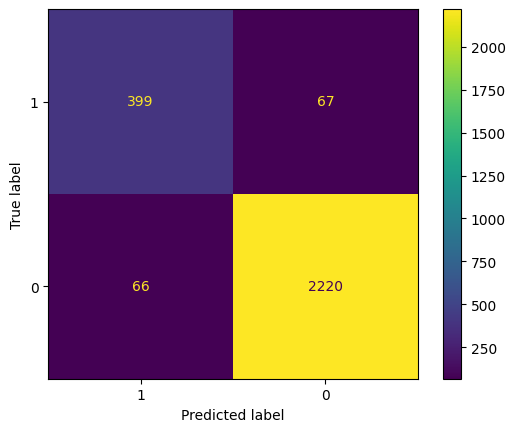

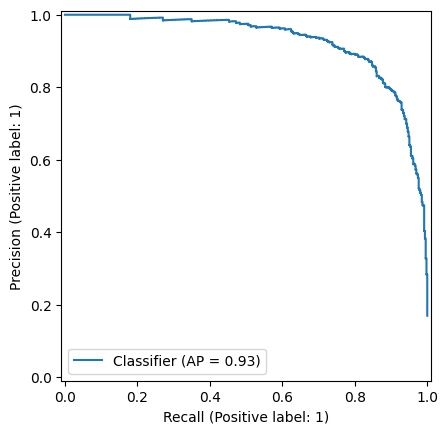

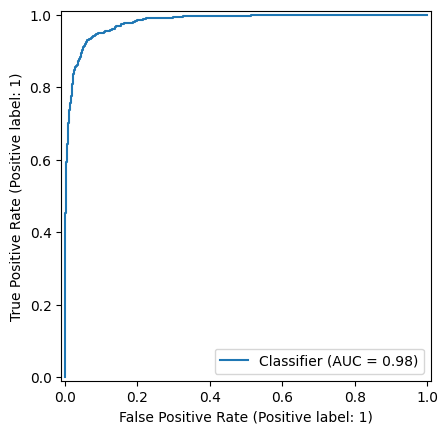

In [44]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay

y_fact, y_pred = [], []
prevalence = test_dataset.y.reshape(-1).numpy().mean()

def test():
  model = model_main.cpu()

  model.eval()
  with torch.no_grad():
    X_test, y_test = test_dataset.X, test_dataset.y
    test_probs = torch.softmax(model_main.forward(test_dataset.X).reshape(-1, 2), dim=-1)[:, 1]
    y_test = y_test.reshape(-1)

    return y_test, test_probs

y_fact, test_probs = test()
y_pred = (test_probs > threshold_main).long()
accuracy = (y_pred == y_fact).float().mean().item()
print(f'Test accuracy: {accuracy}')

print(classification_report(y_fact.numpy(), y_pred.numpy()))

ConfusionMatrixDisplay.from_predictions(y_fact.numpy(), y_pred.numpy(), labels = [1, 0])
PrecisionRecallDisplay.from_predictions(y_fact.numpy(), test_probs.numpy())
print(f'class Prevalence in test selection: {prevalence}')
RocCurveDisplay.from_predictions(y_fact.numpy(), test_probs.numpy())



result = []
for char, pred in zip(test_chars[:200], y_pred.numpy()[:200]): # outs проходят через последний слой fc, дальше y_pred = argmax
            if pred == 1 and result:
                result.append(" ")
            result.append(char)

print([(char, pred) for item in zip(test_chars[:100], y_pred.numpy()[:100]) if item[1] == 1])
print()
"".join(result)


In [45]:
test_text = []
for char, pred in zip(test_chars, y_fact.numpy()):
            if pred == 1 and test_text:
                test_text.append(" ")
            test_text.append(char)

segmented_test_text = []
for char, pred in zip(test_chars, y_pred.numpy()):
            if pred == 1 and segmented_test_text:
                segmented_test_text.append(" ")
            segmented_test_text.append(char)


def show_segmentation_comparison(
    test_text,
    segmented_test_text
):

    test_text = ''.join(test_text).split(' ')
    test_text = ' | '.join(test_text)

    segmented_test_text = ''.join(segmented_test_text).split(' ')
    segmented_test_text = ' | '.join(segmented_test_text)

    print("ЭТАЛОН:")
    print(test_text)

    print("\nПРЕДСКАЗАНИЕ:")
    print(segmented_test_text)

show_segmentation_comparison(test_text, segmented_test_text)

ЭТАЛОН:
чс̑тительскаго | строит҇̋ | жидовьскъ҇мъ | ѻбъ҇чаѥмъ | въслѣдѹющимъ | се | творити | начинающимъ | нѣкъ҇ӻ | же | ѿ | нихъ | и | не | ѻстриженъ҇ | и | не | ѡсщнъ҇ | пѣвьци | и | четьци | бе̃ствѣнаго | закона | поставити | запрещаѥмъ | ӻко | ѿселѣ | не | подобаѥть | въ | клиросъ | хотѧщихъ | пр҇̋водити | нѣкъ҇хъ | на | родъ | възирати | поставлѧѥмаго | нъ | искѹшающе | аще | достоинѣ | бѹдѹть | по | заповѣданъ҇мъ | въ | ѻсщ̃нънъ҇хъ | канонѣхъ | тъл̑ | ѹставомь | прав̑ | июдѣискъ҇мъ | послѣдѹюще | ѡбъ҇чаѥмъ | въ | армѣньстѣи | странѣ | тъкмо | ѥд҇̋нъ҇и | же | сѹть | ѿ | сщ̃еничьскаго | чинѹ | въ | причетъ | приѥмлють | нъ | и | ѥще | к | томѹ | не | приимъшихъ | блг̃ословлениӻ | ѿ | ѥпс̑па | сщ̃наго | пострижениӻ | не | имѹщихъ | сщ̃еньнопѣвьца | твѻрѧть | и | на | амбонѣ | свщ̃енъ҇ӻ | книгъ҇ | почитати | людемъ | повелѣвають | того | ради | ѻбоѥ | се | правило | ѿричають | и | повелѣваѥть | ни | на | родъ | зрѣти | ни | испъ҇товати | аще | ѿ | сщ̃ничьскаго | ѥсть | родѹ | или | и

In [46]:
def get_word_spans(labels):
    spans, start = [], 0
    for i, l in enumerate(labels):
        if l == 1 and i > 0:
            spans.append((start, i)); start = i
    spans.append((start, len(labels)))
    return set(spans)

gt_spans = get_word_spans(y_fact.numpy())
pred_spans = get_word_spans(y_pred.numpy())
tp = len(gt_spans & pred_spans)
p, r = tp/len(pred_spans), tp/len(gt_spans)
print(f"Word-level P/R/F1: {p:.3f}/{r:.3f}/{2*p*r/(p+r):.3f}")

Word-level P/R/F1: 0.665/0.665/0.665
